## Model Pipeline Training
### Baseline Model vs Resnet

ResNet with fine-tuning is outperforming the baseline (~85% vs ~75% val accuracy), less overfitting due to pretrained features + dropout, transfer learning seems to be working well for this small batched datasets.

In [14]:
# External Imports
import sys
from pathlib import Path
import glob
import torch
import torch.optim as optim
import torch.nn as nn
from torchinfo import summary

# Internal Imports
sys.path.insert(0, '../src')
from src.DataIntegrity import data_integrity_check
from src.Dataset import split_patients, get_dataloaders
from src.Model import BaselineModel, build_resnet, fit, plot_loss_acc

In [2]:
data_path = Path("../data/raw/lgg-mri-segmentation/kaggle_3m")
rejected_path = Path("../data/processed/data-integrity")

In [3]:
accepted_data, rejected_data = data_integrity_check(data_path)

[INFO] Data Integrity Checks: 100%|██████████| 112/112 [00:03<00:00, 33.84it/s]

[Info] Data Integrity Pipeline finished
[Info] Segments Accepted = 3929 | Segments Rejected = 0


In [4]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

[INFO]  Splitting dataset with seed 42...
[INFO]  Train Set: 76  | Tumor Ratio: 0.352
[INFO]  Valid Set: 17  | Tumor Ratio: 0.360
[INFO]  Test Set:  17  | Tumor Ratio: 0.372


In [5]:
BATCH_SIZE = 32
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_patients, val_patients, test_patients, batch_size=BATCH_SIZE)

In [6]:
baseline_model = BaselineModel()
device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_model.to(device)

BaselineModel(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Flatten(start_dim=1, end_dim=-1)
  (layer4): Sequential(
    (0): Linear(in_features=96800, out_features=256, bias=True)
    (1): ReLU()
  )
  (layer5): Linear(in_features=256, out_features=2, bias=True)
)

In [7]:
baseline_epoch_data = fit(
    model = baseline_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

Epoch [1/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.7830 | 0.5321 Accuracy: 0.7094 | 0.6922
Epoch [2/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4433 | 0.5258 Accuracy: 0.7708 | 0.6864
Epoch [3/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4260 | 0.5586 Accuracy: 0.7809 | 0.7228
Epoch [4/15 <0:00:17><1/5>] Loss [Train | Validation]: 0.3874 | 0.5557 Accuracy: 0.8017 | 0.7094
Epoch [5/15 <0:00:17><2/5>] Loss [Train | Validation]: 0.3780 | 0.5633 Accuracy: 0.8093 | 0.7285
Epoch [6/15 <0:00:17><3/5>] Loss [Train | Validation]: 0.3708 | 0.5170 Accuracy: 0.8179 | 0.7419
Epoch [7/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.3415 | 0.4672 Accuracy: 0.8402 | 0.7610
Epoch [8/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.3374 | 0.5764 Accuracy: 0.8452 | 0.7476
Epoch [9/15 <0:00:17><1/5>] Loss [Train | Validation]: 0.3184 | 0.5010 Accuracy: 0.8513 | 0.7457
Epoch [10/15 <0:00:17><2/5>] Loss [Train | Validation]: 0.3036 | 0.6804 Accuracy: 0.8549 | 0.7247
Epoch [11/15 <0:00:17><3/5>] 

In [8]:
resnet_model = build_resnet(num_classes=2)
resnet_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
resnet_epoch_data = fit(
    model = resnet_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-3),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

Epoch [1/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.5658 | 0.4058 Accuracy: 0.7037 | 0.7973
Epoch [2/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.5131 | 0.4138 Accuracy: 0.7460 | 0.8011
Epoch [3/15 <0:00:17><1/5>] Loss [Train | Validation]: 0.4913 | 0.4086 Accuracy: 0.7550 | 0.8126
Epoch [4/15 <0:00:17><2/5>] Loss [Train | Validation]: 0.4769 | 0.4081 Accuracy: 0.7640 | 0.8107
Epoch [5/15 <0:00:17><3/5>] Loss [Train | Validation]: 0.4847 | 0.4006 Accuracy: 0.7525 | 0.8050
Epoch [6/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4964 | 0.4239 Accuracy: 0.7575 | 0.7973
Epoch [7/15 <0:00:17><1/5>] Loss [Train | Validation]: 0.4710 | 0.4015 Accuracy: 0.7611 | 0.8069
Epoch [8/15 <0:00:17><2/5>] Loss [Train | Validation]: 0.4641 | 0.4244 Accuracy: 0.7626 | 0.7763
Epoch [9/15 <0:00:17><3/5>] Loss [Train | Validation]: 0.4707 | 0.4212 Accuracy: 0.7626 | 0.7897
Epoch [10/15 <0:00:17><4/5>] Loss [Train | Validation]: 0.4774 | 0.4125 Accuracy: 0.7619 | 0.8050
[INFO] Patience reached, best

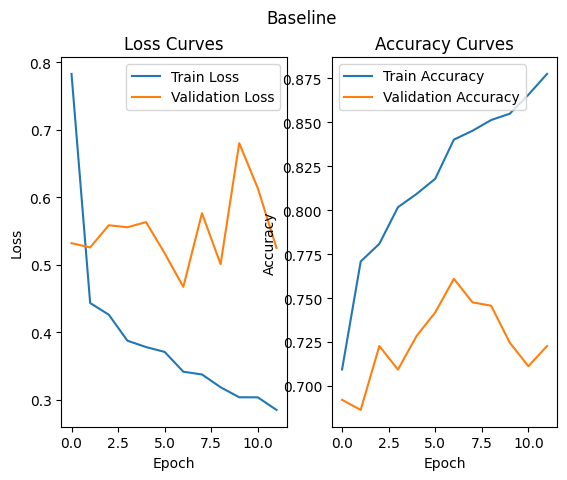

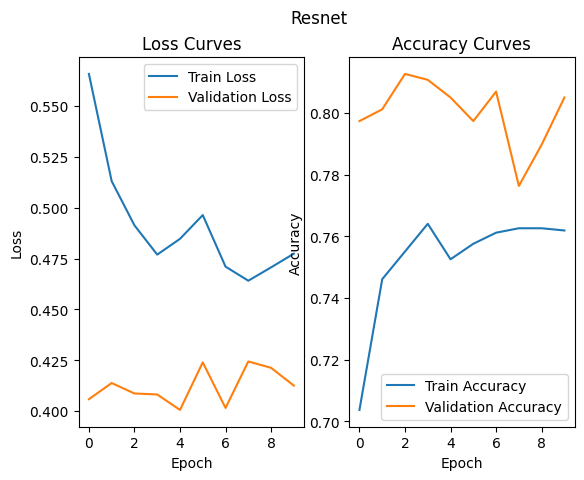

In [10]:
plot_loss_acc(baseline_epoch_data, "Baseline")
plot_loss_acc(resnet_epoch_data, "Resnet")

In [11]:
# Unfreeze Resnet layers and continue training
# Freeze everything
for param in resnet_model.parameters():
  param.requires_grad = False

# Replace fc (automatically unfrozen)
resnet_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=2)
)
# Unfreeze layer4
for param in resnet_model.layer4.parameters():
  param.requires_grad = True

resnet_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
resnet_epoch_data = fit(
    model = resnet_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-4),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

Epoch [1/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4594 | 0.4358 Accuracy: 0.7773 | 0.7878
Epoch [2/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.3055 | 0.3999 Accuracy: 0.8549 | 0.8088
Epoch [3/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.2697 | 0.3852 Accuracy: 0.8836 | 0.8145
Epoch [4/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.2416 | 0.3451 Accuracy: 0.9019 | 0.8394
Epoch [5/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.2212 | 0.3633 Accuracy: 0.9041 | 0.8298
Epoch [6/15 <0:00:17><1/5>] Loss [Train | Validation]: 0.1828 | 0.4042 Accuracy: 0.9256 | 0.8164
Epoch [7/15 <0:00:17><2/5>] Loss [Train | Validation]: 0.1911 | 0.3460 Accuracy: 0.9195 | 0.8394
Epoch [8/15 <0:00:17><3/5>] Loss [Train | Validation]: 0.1935 | 0.3516 Accuracy: 0.9156 | 0.8604
Epoch [9/15 <0:00:17><4/5>] Loss [Train | Validation]: 0.1818 | 0.3535 Accuracy: 0.9249 | 0.8566
[INFO] Patience reached, best epoch was 4 with 0.3451 validation loss.


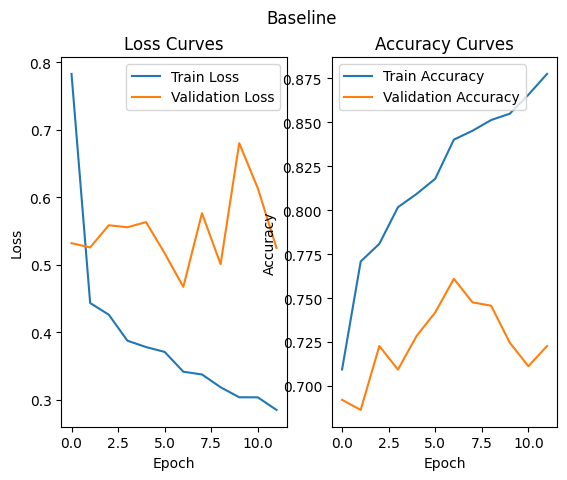

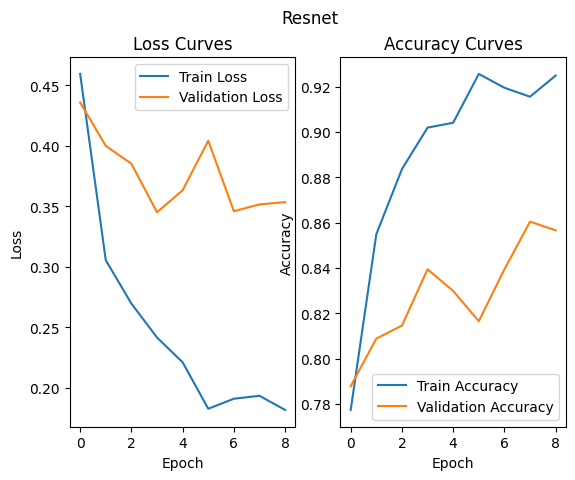

In [13]:
plot_loss_acc(baseline_epoch_data, "Baseline")
plot_loss_acc(resnet_epoch_data, "Resnet")